In [2]:
!pip install pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression #for polynomial regression
from sklearn.preprocessing import PolynomialFeatures #for polyonomial regression
from sklearn.neural_network import MLPRegressor #for feedforward neural network regression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
train_data = pd.read_csv('train.csv')
validation_data = pd.read_csv('val.csv')


In [4]:
#identifying features and target variable
X_train = train_data.drop('y', axis=1) #feature for training
y_train = train_data['y'] #target variable for training

X_val = validation_data.drop('y', axis=1) #x feature for validation
y_val = validation_data['y'] #target variable for validation


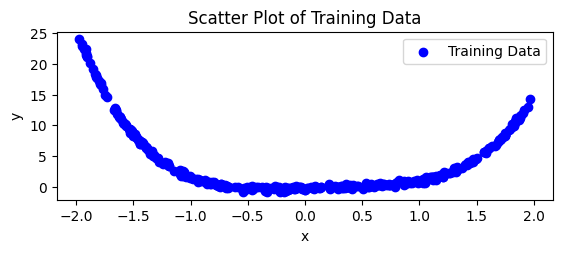

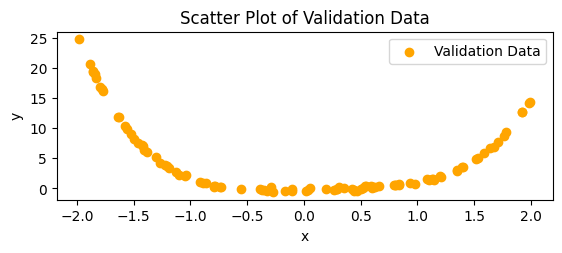

In [5]:
plt.subplot(2,1,2)
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.scatter(X_val, y_val, color='orange', label='Validation Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Validation Data')
plt.legend()
plt.show()


***Interpretation***
- the data above is plotted for the training and validation set
- the input variable is x and the output variable is y
- It forms a structure similar to a polynomial regression with degree 2

In [12]:
#polynomial regression
degree = 4 #degree of the polynomial
poly_features = PolynomialFeatures(degree=degree)
X_train_poly_four = poly_features.fit_transform(X_train) #transforming the training data to include
#polynomial features
X_val_poly = poly_features.transform(X_val) #transforming the validation data to include polynomial
#features
poly_model = LinearRegression() #creating a linear regression model
poly_model.fit(X_train_poly_four, y_train) #fitting the model to the training data
y_val_pred_poly = poly_model.predict(X_val_poly) #predicting the target variable for
#validation data
mse_poly = mean_squared_error(y_val, y_val_pred_poly) #calculating mean squared error for polynomial regression
r2_poly = r2_score(y_val, y_val_pred_poly) #calculating R-squared score for polynomial regression
print(f'Polynomial Regression (degree={degree}): MSE={mse_poly:.4f}, R2={r2_poly:.4f}')
print(f'Polynomial Regression Coefficients: {poly_model.coef_}, Intercept: {poly_model.intercept_}')


Polynomial Regression (degree=4): MSE=0.0307, R2=0.9991
Polynomial Regression Coefficients: [ 0.          0.50759346  0.28989804 -0.80366203  1.20539343], Intercept: -0.21463817306569632


In [16]:
#implementing feedforward neural network regression
nn_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='sgd', max_iter=1000, random_state=42) #creating a feedforward neural network regression model
nn_model.fit(X_train, y_train) #fitting the model to the training data
y_val_pred_nn = nn_model.predict(X_val) #predicting the target variable for validation
mse_nn = mean_squared_error(y_val, y_val_pred_nn) #calculating mean squared error for neural network regression
r2_nn = r2_score(y_val, y_val_pred_nn) #calculating R-squared score for neural network regression
print(f'Feedforward Neural Network Regression: MSE={mse_nn:.4f}, R2={r2_nn:.4f}')


Feedforward Neural Network Regression: MSE=0.5437, R2=0.9848


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
 #checking the architecture of the neural network model


Neural Network Architecture: (100,)
